In [1]:
# Import necessary libraries
import pandas as pd
import nltk
import re
import string
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from imblearn.over_sampling import SMOTE # Testing SMOTE to see if it is worth using in our models
import matplotlib.pyplot as plt
import seaborn as sns

# Download necessary NLTK resources
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Function to preprocess text with lemmatization
def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    # Ensure text is string type
    text = str(text)
    text = text.lower()  # Lowercase text
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'\[.*?\]', '', text)  # Remove brackets
    text = re.sub(r'\W+', ' ', text)  # Remove special characters
    text = re.sub(r'\d+', '', text)  # Remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = " ".join([word for word in text.split() if word not in stop_words])  # Remove stopwords
    return text

In [3]:
# Combine fake and real news into a single dataframe
fake_news = pd.read_csv('fake_cleaned.csv')
real_news = pd.read_csv('true_cleaned.csv')

fake_news['label'] = 0  # 0 for fake
real_news['label'] = 1  # 1 for real
data = pd.concat([fake_news, real_news], ignore_index=True)

# Shuffle the data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data['text'] = data['text'].apply(preprocess_text)
print(data.head())

                                               title  \
0  BEHIND THE CURTAIN: How Obama Plans To Prevent...   
1  WHY HILLARY LOVES The Idea Of Barack Obama As ...   
2  Hillary Clinton’s ‘Presidency’ has Already Beg...   
3  Russia's Putin: ready to meet Trump any moment...   
4  Syria calls on U.N. Security Council to condem...   

                                                text       subject  \
0  nothing obama executive order gun grab barack ...      politics   
1  remember would seem like far fetched idea demo...     left-news   
2  st century wire says one glaring conclusion la...       US_News   
3  moscow reuters russian president vladimir puti...  politicsNews   
4  beirut reuters syria foreign ministry thursday...     worldnews   

                 date  label  
0         Jan 6, 2016      0  
1        Jul 31, 2016      0  
2  September 27, 2016      0  
3  December 13, 2016       1  
4   November 2, 2017       1  


In [4]:
# Split the dataset into features (X) and labels (y)
X = data['text']
y = data['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature extraction using TF-IDF
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=10000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)


# Initialize the models
logistic_regression = LogisticRegression(class_weight='balanced', random_state=42)
naive_bayes = MultinomialNB()
naive_bayes_smote = MultinomialNB()

In [5]:
# Train the Logistic Regression model
logistic_regression.fit(X_train_tfidf, y_train)

# Train the Naive Bayes model
naive_bayes.fit(X_train_tfidf, y_train)

# Train the Naive Bayes SMOTE model
naive_bayes_smote.fit(X_train_resampled, y_train_resampled)

MultinomialNB()

In [6]:
y_pred_lr = logistic_regression.predict(X_test_tfidf)
y_pred_nb = naive_bayes.predict(X_test_tfidf)
y_pred_nb_smote = naive_bayes_smote.predict(X_test_tfidf)

# Evaluate Logistic Regression
print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Evaluate Naive Bayes
print("\nNaive Bayes Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1-Score:", f1_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

# Evaluate Naive Bayes with SMOTE
print("\nNaive Bayes Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb_smote))
print("Precision:", precision_score(y_test, y_pred_nb_smote))
print("Recall:", recall_score(y_test, y_pred_nb_smote))
print("F1-Score:", f1_score(y_test, y_pred_nb_smote))
print(classification_report(y_test, y_pred_nb_smote))

print("\nComparison:")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Naive Bayes - SMOTE Accuracy: {accuracy_score(y_test, y_pred_nb_smote):.4f}")

Logistic Regression Performance:
Accuracy: 0.9885667138142386
Precision: 0.9853600944510036
Recall: 0.9916825095057035
F1-Score: 0.9885111927040152
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4276
           1       0.99      0.99      0.99      4208

    accuracy                           0.99      8484
   macro avg       0.99      0.99      0.99      8484
weighted avg       0.99      0.99      0.99      8484


Naive Bayes Performance:
Accuracy: 0.9269212635549269
Precision: 0.9129834254143646
Recall: 0.9424904942965779
F1-Score: 0.9275023386342376
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      4276
           1       0.91      0.94      0.93      4208

    accuracy                           0.93      8484
   macro avg       0.93      0.93      0.93      8484
weighted avg       0.93      0.93      0.93      8484


Naive Bayes Performance:
Accuracy: 0.9431871758604432
Pr

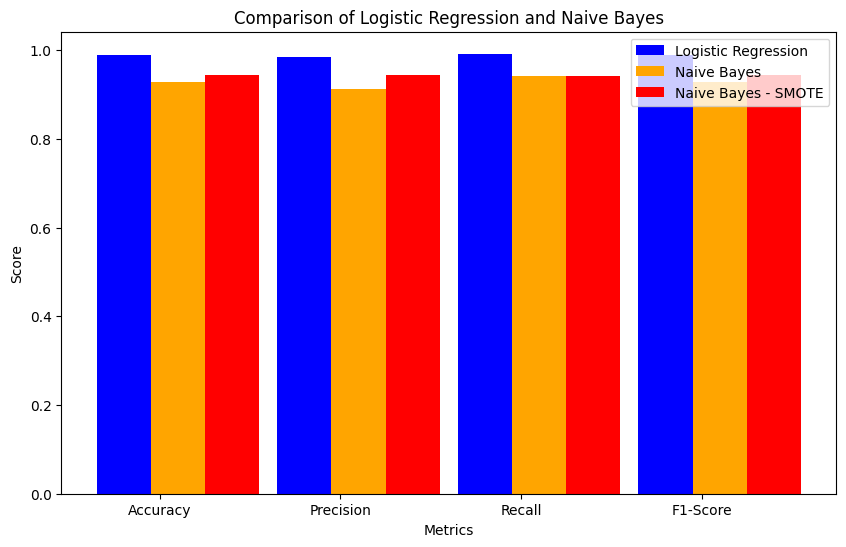

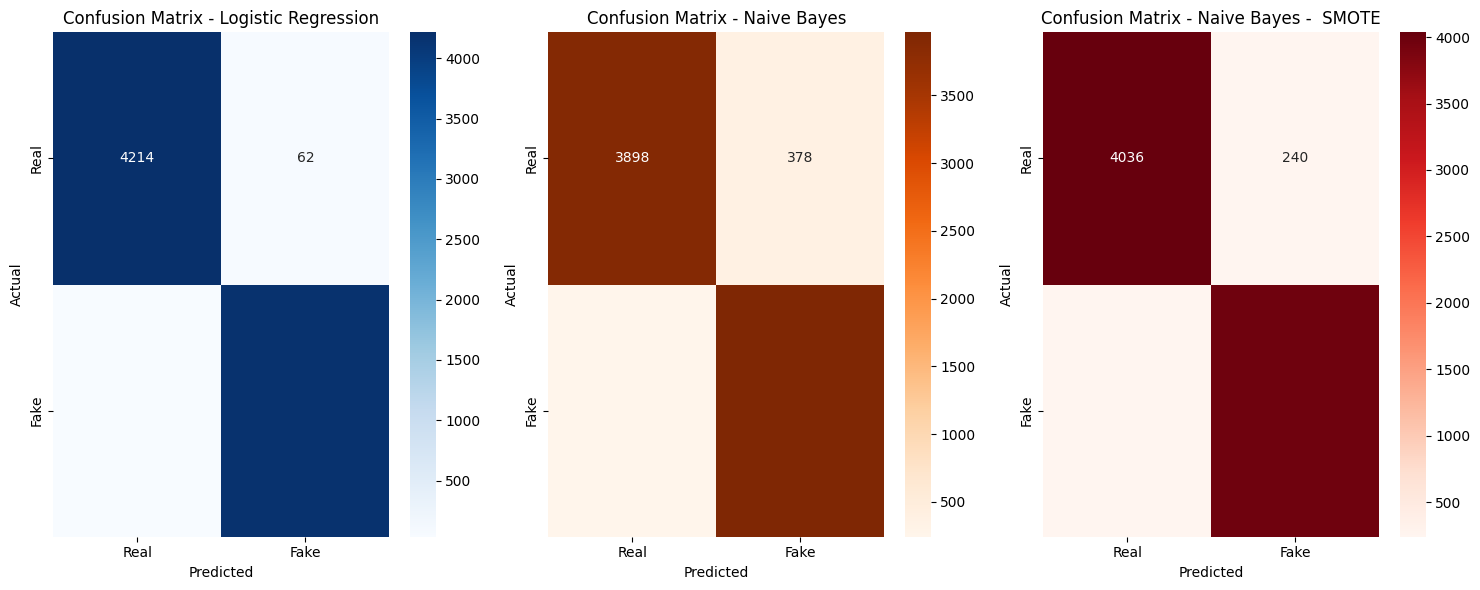

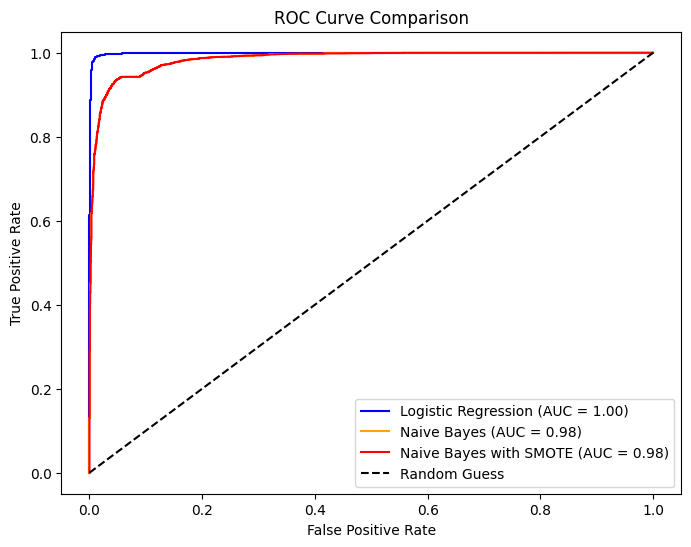

In [7]:
# Visualization 1: Bar Chart for Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]
nb_scores = [
    accuracy_score(y_test, y_pred_nb),
    precision_score(y_test, y_pred_nb),
    recall_score(y_test, y_pred_nb),
    f1_score(y_test, y_pred_nb)
]
nb_scores_smote= [
    accuracy_score(y_test, y_pred_nb_smote),
    precision_score(y_test, y_pred_nb_smote),
    recall_score(y_test, y_pred_nb_smote),
    f1_score(y_test, y_pred_nb_smote)
]

x = range(len(metrics))
plt.figure(figsize=(10, 6))
plt.bar(x, lr_scores, width=0.3, label='Logistic Regression', color='blue')
plt.bar([i + 0.3 for i in x], nb_scores, width=0.3, label='Naive Bayes', color='orange')
plt.bar([i + 0.6 for i in x], nb_scores_smote, width=0.3, label='Naive Bayes - SMOTE', color='red')
plt.xticks([i + 0.2 for i in x], metrics)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Comparison of Logistic Regression and Naive Bayes')
plt.legend()
plt.show()

# Visualization 2: Confusion Matrices
plt.figure(figsize=(15, 6))

# Confusion Matrix for Logistic Regression
plt.subplot(1, 3, 1)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Confusion Matrix for Naive Bayes
plt.subplot(1, 3, 2)
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Confusion Matrix for Naive Bayes
plt.subplot(1, 3, 3)
cm_nb = confusion_matrix(y_test, y_pred_nb_smote)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Reds', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - Naive Bayes -  SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Visualization 3: ROC Curves
plt.figure(figsize=(8, 6))

# ROC Curve for Logistic Regression
y_pred_prob_lr = logistic_regression.predict_proba(X_test_tfidf)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})', color='blue')

# ROC Curve for Naive Bayes
y_pred_prob_nb = naive_bayes.predict_proba(X_test_tfidf)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})', color='orange')

# ROC Curve for Naive Bayes - SMOTE
y_pred_prob_nb_smote = naive_bayes_smote.predict_proba(X_test_tfidf)[:, 1]
fpr_nb_smote, tpr_nb_smote, _ = roc_curve(y_test, y_pred_prob_nb_smote)
roc_auc_nb_smote = auc(fpr_nb_smote, tpr_nb_smote)
plt.plot(fpr_nb_smote, tpr_nb_smote, label=f'Naive Bayes with SMOTE (AUC = {roc_auc_nb_smote:.2f})', color='red')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

#### In this experiment, we were comparing the LR and NB models while also testing if SMOTE would help in the model's accuracies. In this case, it did help the Naive Bayes models to improve by a slight margin, however, this margin is to little to be noticable when applied to real-life sceanrios. For this reason, it's decided that SMOTE will not be used for the other traditional models

Improved Confusion Matrixes will be made in the final evaulation


We use SHAP to visualize the contribution of each input feature (e.g., words, tokens) to a model's prediction

C:\Users\isaac\anaconda3\envs\py310\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


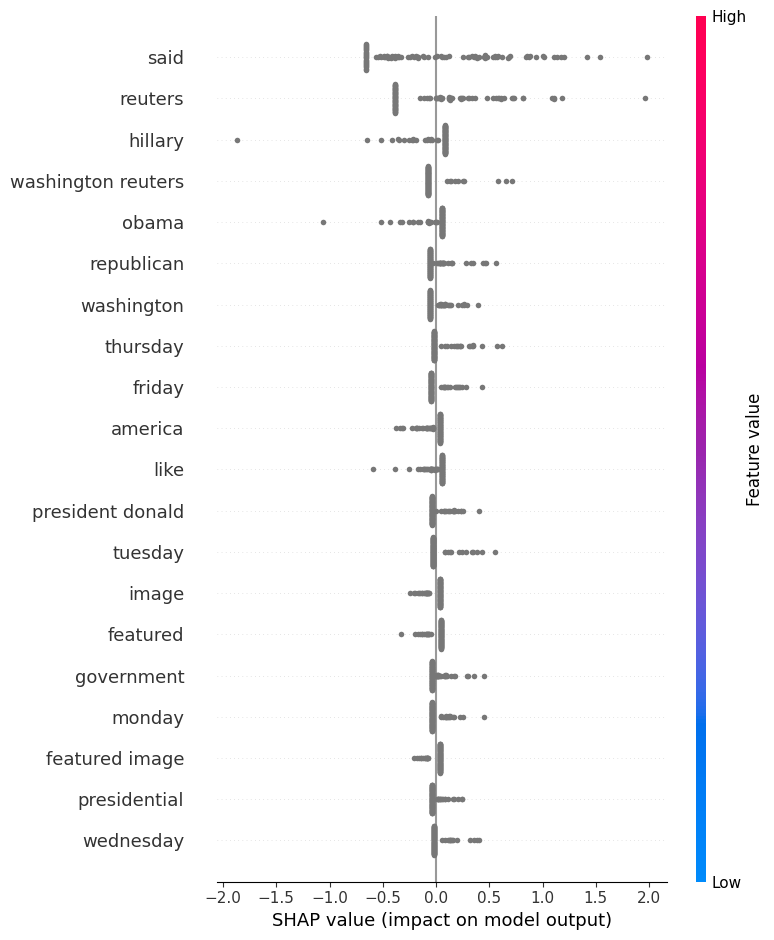

In [8]:
import shap

# Initialize SHAP explainer for Logistic Regression
explainer_lr = shap.LinearExplainer(logistic_regression, X_train_tfidf, feature_perturbation="interventional")

# Calculate SHAP values for a subset of test data
shap_values_lr = explainer_lr.shap_values(X_test_tfidf[:100])  # Use a small subset for speed

# Visualize explanations for the first prediction
shap.summary_plot(shap_values_lr, X_test_tfidf[:100], feature_names=tfidf_vectorizer.get_feature_names_out())

Force Plot for First Prediction:


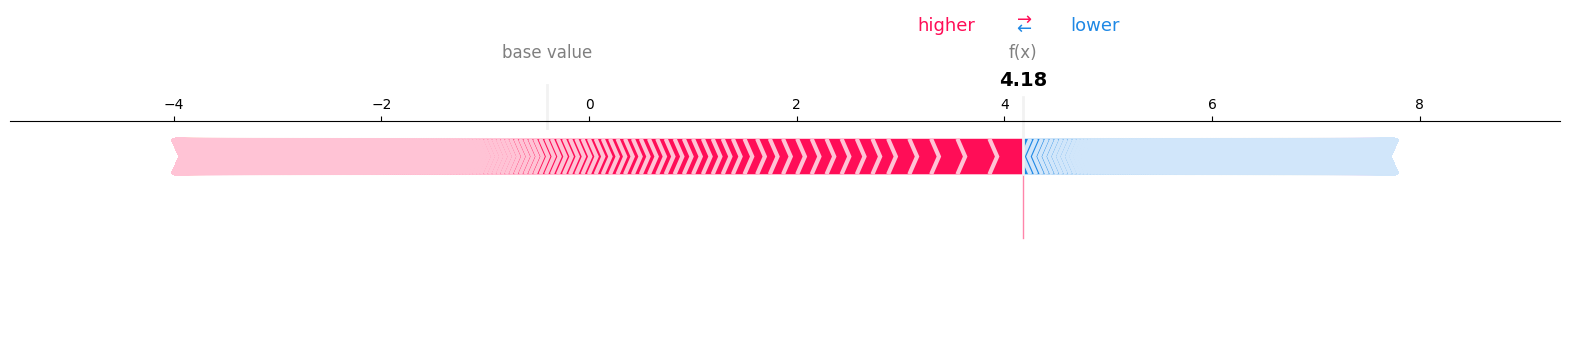

In [9]:
shap.initjs()
X_test_tfidf_dense = X_test_tfidf[:100].toarray()
shap_values_dense = shap_values_lr.toarray() if hasattr(shap_values_lr, "toarray") else shap_values_lr

print("Force Plot for First Prediction:")

display(shap.force_plot(
    explainer_lr.expected_value,
    shap_values_dense[0,:],  
    X_test_tfidf_dense[0,:],  
    feature_names=tfidf_vectorizer.get_feature_names_out(),
    matplotlib=True,
    show = False
))

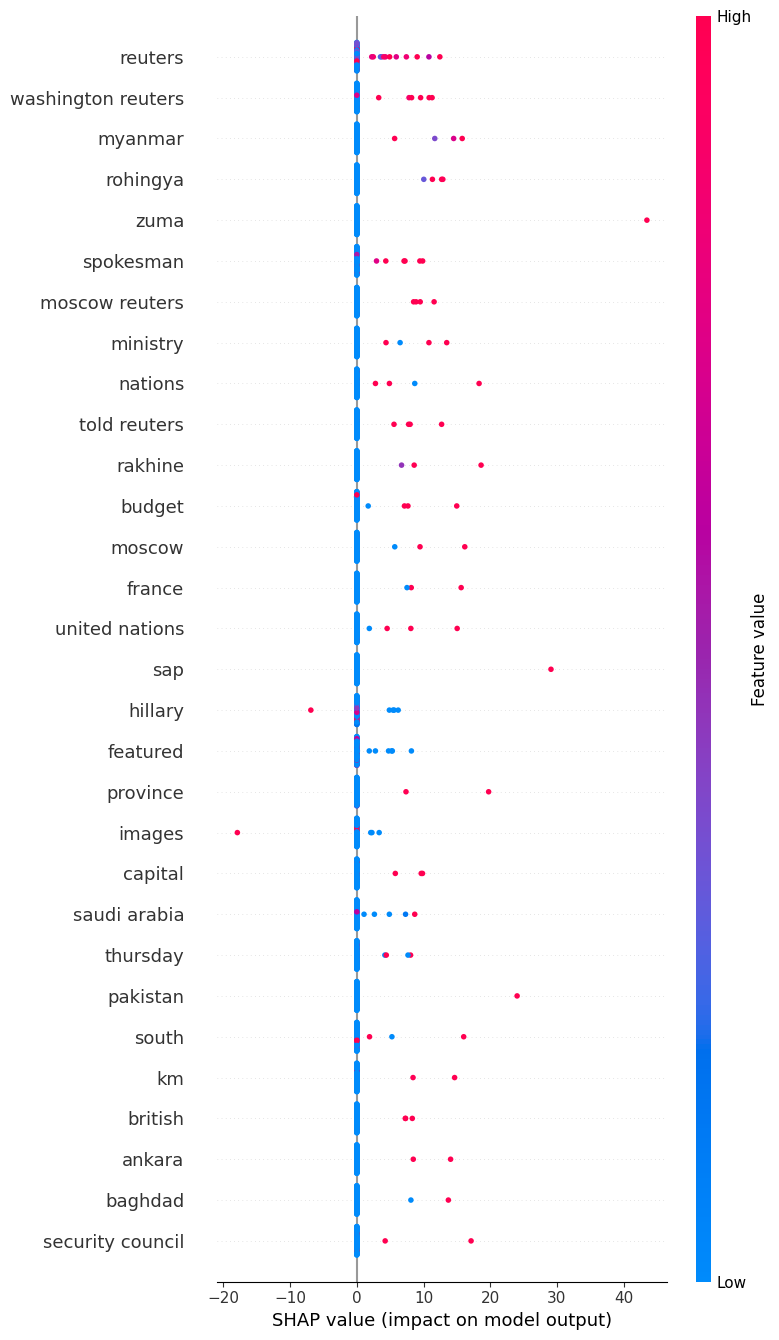

In [10]:
import numpy as np
from scipy.special import logit  # For converting probabilities to log-odds

from sklearn.feature_selection import SelectKBest, chi2

# Feature Selection (Reduce Dimensionality)
selector = SelectKBest(chi2, k=500)  # Keep top 500 features
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf[:100])  

# Retrain NB on selected features
naive_bayes.fit(X_train_selected, y_train)

# SHAP Explanation with Stability Improvements
explainer_nb = shap.KernelExplainer(
    lambda x: logit(naive_bayes.predict_proba(x)[:, 1]),
    data=shap.sample(X_train_selected.toarray(), 100), 
    link="logit",
    l1_reg="num_features(50)"  # Regularization
)

# Calculate SHAP values with increased samples
shap_values_nb = explainer_nb.shap_values(
    X_test_selected.toarray(),
    nsamples=500,  
    silent=True  
)

# Visualize Top Features
shap.summary_plot(
    shap_values_nb,
    X_test_selected.toarray(),
    feature_names=np.array(tfidf_vectorizer.get_feature_names_out())[selector.get_support()],
    plot_type="dot",
    max_display=30 
)


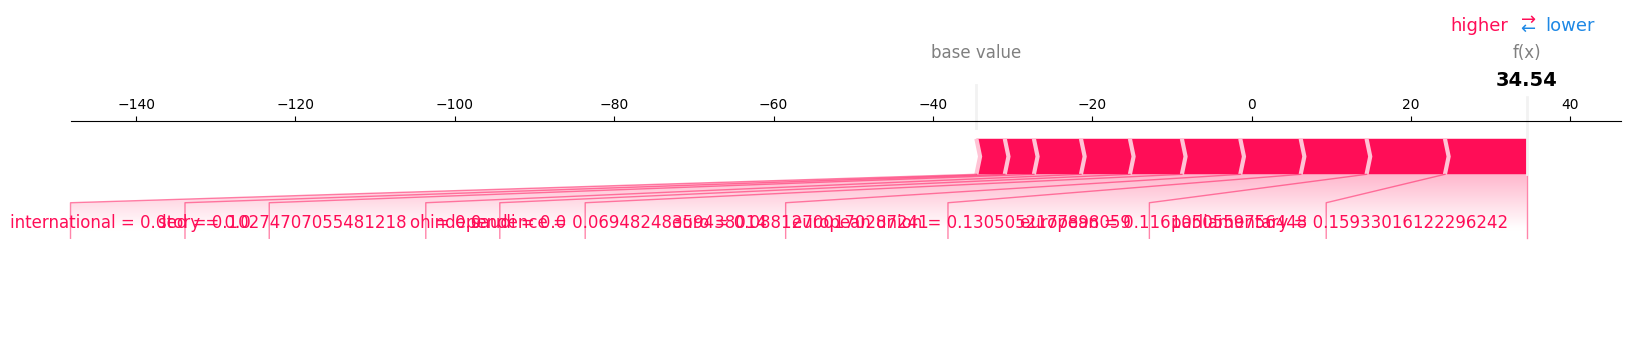

In [11]:
shap.initjs()

selected_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())[selector.get_support()]

display(shap.force_plot(
    explainer_nb.expected_value,
    shap_values_nb[0,:],  
    X_test_selected[0,:].toarray().flatten(),  
    feature_names=selected_feature_names,
    matplotlib=True,
    show = False
))

In [12]:
import numpy as np
np.save("shap_values_lr.npy", shap_values_lr)
np.save("shap_values_nb.npy", shap_values_nb)